<a href="https://colab.research.google.com/github/jess22jess/SIMULACI-N-II/blob/main/L%C3%ADnea_de_Espera_0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

Dónde lambda es la tasa de llegadas, mu es la tasa de servicio, T el tiempo después del cual no entran más clientes y num_ejecuciones el número de ejecuciones de simulación

In [ ]:
lambda_ = 4.0
mu = 6.0
T = 10.0
num_ejecuciones = 5000

In [ ]:
def tiempo_entre_llegadas():  #Proceso de Poisson
    return r.expovariate(1.0 / lambda_)

In [ ]:
def tiempo_servicio():
    return r.expovariate(1.0 / mu)

t: tiempo

$N_A$ : número de llegadas

$N_D$ : número de salidas

---

**Lista de eventos LE = $t_a, t_d$:**

$t_a$: tiempo de la siguiente llegada

$t_d$: tiempo de la isguiente salida

Nota: Si no hay servicio $t_d$ es infinito

Variables de salida

**A(i)**: Hora de llegada del cliente **i**

**D(i)**: Hora de salida del cliente **i**

$T_p$ tiempo de salida del último cliente posterior a T

In [ ]:
def simular_una_ejecucion():
    t = 0.0
    NA = 0
    ND = 0
    n = 0
    tA = tiempo_entre_llegadas()
    tD = np.inf
    A = []
    D = []

    while True: # Caso 1: Llegada antes que salida y antes de T
        if tA <= tD and tA <= T:
            t = tA
            NA += 1
            n += 1
            A.append(t)
            tA = t + tiempo_entre_llegadas()
            if n == 1:
                tD = t + tiempo_servicio()

        elif tD < tA and tD != np.inf:   # Caso 2: Salida antes que llegada, y antes de T
            t = tD
            n -= 1
            ND += 1
            D.append(t)
            if n > 0:
                tD = t + tiempo_servicio()
            else:
                tD = np.inf

        elif tA > T and n == 0:    # Caso 3: No hay más llegadas (tA > T) y se vacía el sistema
            break

        elif tA > T and n > 0:  # Caso 4: No hay llegadas pero aún hay clientes en sistema
            t = tD
            n -= 1
            ND += 1
            D.append(t)

            if n > 0:
                tD = t + tiempo_servicio()
            else:
                tD = np.inf
                break

    ultima_salida = D[-1] if D else 0  # Calculamos Tp = tiempo posterior a T del último cliente
    Tp = max(ultima_salida - T, 0)

    tiempos_en_sistema = [D[i] - A[i] for i in range(len(A))]

    return tiempos_en_sistema, Tp, NA, ND

In [ ]:
tiempos_totales = []
Tp_totales = []

In [ ]:
for _ in range(num_ejecuciones):
    tiempos, Tp, NA, ND = simular_una_ejecucion()
    tiempos_totales.extend(tiempos)
    Tp_totales.append(Tp)

# Estimaciones
tiempo_promedio_en_sistema = np.mean(tiempos_totales)
tiempo_promedio_Tp = np.mean(Tp_totales)

RESULTADOS DE SIMULACIÓN (λ=4.0, μ=6.0, T=10.0)
Número de ejecuciones        : 5000
Total de clientes simulados  : 12330
Tiempo promedio en sistema   : 11.4501 unidades de tiempo
Tiempo posterior a T promedio: 9.7627 unidades de tiempo


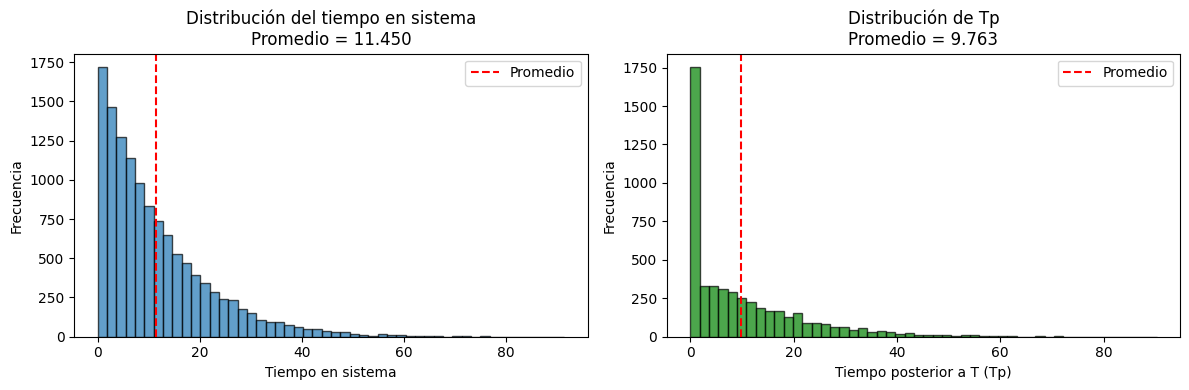

In [ ]:

print("="*50)
print(f"RESULTADOS DE SIMULACIÓN (λ={lambda_}, μ={mu}, T={T})")
print("="*50)
print(f"Número de ejecuciones        : {num_ejecuciones}")
print(f"Total de clientes simulados  : {len(tiempos_totales)}")
print(f"Tiempo promedio en sistema   : {tiempo_promedio_en_sistema:.4f} unidades de tiempo")
print(f"Tiempo posterior a T promedio: {tiempo_promedio_Tp:.4f} unidades de tiempo")
print("="*50)

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histograma tiempos en sistema
ax1.hist(tiempos_totales, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Tiempo en sistema')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Distribución del tiempo en sistema\nPromedio = {tiempo_promedio_en_sistema:.3f}')
ax1.axvline(tiempo_promedio_en_sistema, color='red', linestyle='--', label='Promedio')
ax1.legend()

# Histograma Tp
ax2.hist(Tp_totales, bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Tiempo posterior a T (Tp)')
ax2.set_ylabel('Frecuencia')
ax2.set_title(f'Distribución de Tp\nPromedio = {tiempo_promedio_Tp:.3f}')
ax2.axvline(tiempo_promedio_Tp, color='red', linestyle='--', label='Promedio')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [ ]:
def generar_tiempo_llegada(t_actual, lam):
    r = r.random()
    return t_actual - (np.log(r) / lam)

In [ ]:
def generar_tiempo_servicio(mu):
    r = r.random()
    return -(np.log(r) / mu)

In [ ]:
def simular_linea_espera(lam, mu, T):
    t = 0.0
    N_A = 0
    N_D = 0
    n = 0

    A = {}  # Registra A(i): hora de llegada del cliente i
    D = {}  # Registra D(i): hora de salida del cliente i

    # Generar la primera llegada T_0 y configurar lista de eventos (LE)
    t_A = generar_tiempo_llegada(t, lam)
    t_D = float("inf")  # Al principio no hay nadie en servicio

    # --- BUCLE PRINCIPAL DE SIMULACIÓN ---
    while True:
        # Caso 1: El próximo evento es una llegada y ocurre antes del tiempo límite T
        if t_A <= t_D and t_A <= T:
            t = t_A  # Avanzar el tiempo
            N_A += 1  # Incrementar contador de llegadas
            n += 1  # Un cliente más en el sistema

            # Generar la hora de la siguiente llegada
            t_A = generar_tiempo_llegada(t, lam)

            # Si el cliente que llegó encontró el sistema vacío, pasa directo a servicio
            if n == 1:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

            # Guardar datos de salida de la llegada
            A[N_A] = t

        # Caso 2: El próximo evento es una salida y ocurre antes o en el tiempo límite T
        elif t_D < t_A and t_D <= T:
            t = t_D  # Avanzar el tiempo
            n -= 1  # El cliente sale del sistema
            N_D += 1  # Incrementar contador de salidas

            # Guardar datos de salida del cliente que se va
            D[N_D] = t

            # Si quedan clientes en fila, el siguiente pasa a ser atendido
            if n == 0:
                t_D = float("inf")
            else:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

        # Caso 3: Ya pasó el tiempo límite T, pero todavía quedan clientes en el sistema
        elif min(t_A, t_D) > T and n > 0:
            t = t_D  # Avanzar el tiempo al de la salida
            n -= 1  # El cliente sale del sistema
            N_D += 1  # Incrementar contador de salidas

            # Guardar datos de salida
            D[N_D] = t

            # Si todavía quedan más clientes, atender al siguiente
            if n > 0:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

        # Caso 4: Ya pasó el tiempo límite T y el sistema se ha vaciado por completo
        elif min(t_A, t_D) > T and n == 0:
            # Calcular el tiempo extra que el servidor se quedó después de T
            T_p = max(t - T, 0)
            break  # Terminar la ejecución de la simulación

    # --- CÓMPUTO DE RESULTADOS DE LA EJECUCIÓN ---
    # (a) Tiempo promedio que pasa un cliente dentro del sistema (D(i) - A(i))
    tiempos_en_sistema = [D[i] - A[i] for i in range(1, N_D + 1)]
    tiempo_promedio_sistema = (
        sum(tiempos_en_sistema) / N_D if N_D > 0 else 0.0
    )

    return {
        "N_A": N_A,
        "N_D": N_D,
        "Tiempo_Promedio_Sistema": tiempo_promedio_sistema,
        "T_p": T_p,
    }

In [ ]:




def simular_linea_espera(lam, mu, T):
    # --- INICIALIZACIÓN ---
    t = 0.0
    N_A = 0
    N_D = 0
    n = 0

    # Listas para recopilar datos de salida
    A = {}  # Registra A(i): hora de llegada del cliente i
    D = {}  # Registra D(i): hora de salida del cliente i

    # Generar la primera llegada T_0 y configurar lista de eventos (LE)
    t_A = generar_tiempo_llegada(t, lam)
    t_D = float("inf")  # Al principio no hay nadie en servicio

    # --- BUCLE PRINCIPAL DE SIMULACIÓN ---
    while True:
        # Caso 1: El próximo evento es una llegada y ocurre antes del tiempo límite T
        if t_A <= t_D and t_A <= T:
            t = t_A  # Avanzar el tiempo
            N_A += 1  # Incrementar contador de llegadas
            n += 1  # Un cliente más en el sistema

            # Generar la hora de la siguiente llegada
            t_A = generar_tiempo_llegada(t, lam)

            # Si el cliente que llegó encontró el sistema vacío, pasa directo a servicio
            if n == 1:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

            # Guardar datos de salida de la llegada
            A[N_A] = t

        # Caso 2: El próximo evento es una salida y ocurre antes o en el tiempo límite T
        elif t_D < t_A and t_D <= T:
            t = t_D  # Avanzar el tiempo
            n -= 1  # El cliente sale del sistema
            N_D += 1  # Incrementar contador de salidas

            # Guardar datos de salida del cliente que se va
            D[N_D] = t

            # Si quedan clientes en fila, el siguiente pasa a ser atendido
            if n == 0:
                t_D = float("inf")
            else:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

        # Caso 3: Ya pasó el tiempo límite T, pero todavía quedan clientes en el sistema
        elif min(t_A, t_D) > T and n > 0:
            t = t_D  # Avanzar el tiempo al de la salida
            n -= 1  # El cliente sale del sistema
            N_D += 1  # Incrementar contador de salidas

            # Guardar datos de salida
            D[N_D] = t

            # Si todavía quedan más clientes, atender al siguiente
            if n > 0:
                Y = generar_tiempo_servicio(mu)
                t_D = t + Y

        # Caso 4: Ya pasó el tiempo límite T y el sistema se ha vaciado por completo
        elif min(t_A, t_D) > T and n == 0:
            # Calcular el tiempo extra que el servidor se quedó después de T
            T_p = max(t - T, 0)
            break  # Terminar la ejecución de la simulación

    # --- CÓMPUTO DE RESULTADOS DE LA EJECUCIÓN ---
    # (a) Tiempo promedio que pasa un cliente dentro del sistema (D(i) - A(i))
    tiempos_en_sistema = [D[i] - A[i] for i in range(1, N_D + 1)]
    tiempo_promedio_sistema = (
        sum(tiempos_en_sistema) / N_D if N_D > 0 else 0.0
    )

    return {
        "N_A": N_A,
        "N_D": N_D,
        "Tiempo_Promedio_Sistema": tiempo_promedio_sistema,
        "T_p": T_p,
    }


# --- EJEMPLO DE EJECUCIÓN ---
# Parámetros solicitados: lambda = 4, mu = 6. Definimos un tiempo de corte T = 100
LAMBDA_VAL = 4
MU_VAL = 6
TIEMPO_CORTE = 100

resultado = simular_linea_espera(LAMBDA_VAL, MU_VAL, TIEMPO_CORTE)

print("=== RESULTADOS DE LA SIMULACIÓN ===")
print(f"Total de clientes que llegaron (N_A): {resultado['N_A']}")
print(f"Total de clientes que salieron (N_D): {resultado['N_D']}")
print(
    f"Tiempo promedio de un cliente en el sistema: {resultado['Tiempo_Promedio_Sistema']:.4f} unidades de tiempo"
)
print(
    f"Tiempo extra del servidor después de T (T_p): {resultado['T_p']:.4f} unidades de tiempo"
)

=== RESULTADOS DE LA SIMULACIÓN ===
Total de clientes que llegaron (N_A): 431
Total de clientes que salieron (N_D): 431
Tiempo promedio de un cliente en el sistema: 0.3788 unidades de tiempo
Tiempo extra del servidor después de T (T_p): 0.2369 unidades de tiempo
